# Loading

In [1]:
import pandas as pd
import numpy as np
import os
GTE_DIR=os.environ["GTE_DIR"]
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.chunking_data import ChunkLoader

In [2]:
config = read_config(
    os.path.join('/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/config_n2o.yaml'))
analyze_year=True
# years=[2007,2008,2009,2010,2011,2012,2013,2014,2015]
years = [year for year in range(2007, 2017)]
glac_threshold=0.4


In [3]:
dataset = ChunkLoader(years,config=config)

Cloud_fps: {2007: '/wolke_scratch/dnikolo/Final_results/2007_all.parquet', 2008: '/wolke_scratch/dnikolo/Final_results/2008_all.parquet', 2009: '/wolke_scratch/dnikolo/Final_results/2009_all.parquet', 2010: '/wolke_scratch/dnikolo/Final_results/2010_all.parquet', 2011: '/wolke_scratch/dnikolo/Final_results/2011_all.parquet', 2012: '/wolke_scratch/dnikolo/Final_results/2012_all.parquet', 2013: '/wolke_scratch/dnikolo/Final_results/2013_all.parquet', 2014: '/wolke_scratch/dnikolo/Final_results/2014_all.parquet', 2015: '/wolke_scratch/dnikolo/Final_results/2015_all.parquet', 2016: '/wolke_scratch/dnikolo/Final_results/2016_all.parquet'}


In [4]:
def is_stratiform(cloud_series: pd.Series) -> pd.Series:
    """
    Given a Series of cloud‐type names (possibly containing None/NaN),
    return a Boolean mask that’s True only for stratiform clouds.
    """
    stratiform = {
        "Altostratus",
        "Nimbostratus",
        "Cirrostratus",
        "Stratocumulus",
        "Stratus",
    }
    # .isin(...) yields False for None/NaN automatically
    return cloud_series.isin(stratiform)

def is_maritime(temp_cloud):
    if temp_cloud["avg_lat"] > 0:
        return temp_cloud["avg_lon"] < -10
    else:
        return True
    
def is_near_temp_boundaries(sample):
    """ Check if the minimum or maximum temperature in the cloud sample is within 1 degree of any temperature boundary"""
    temp_boundaries = 273.15 + np.array([-36,-30,-24,-18,-12,-6])
    temp_boundaries = np.tile(temp_boundaries[np.newaxis,:],(sample.shape[0],1)) 
    min_temps = np.tile((sample["ctt_hist"]).map(np.min).to_numpy().T,(6,1)).T
    max_temps = np.tile((sample["ctt_hist"]).map(np.max).to_numpy().T,(6,1)).T
    dist_to_lower_bin = np.abs(temp_boundaries - min_temps).min(axis=1)
    dist_to_higher_bin = np.abs(temp_boundaries - max_temps).min(axis=1)
    return (dist_to_lower_bin<1) | (dist_to_higher_bin<1)


In [5]:
def calculate_pole_temp_occurance_rate_glac_possible_filtered(dfs):
    cloud_chunk , _ , _ = dfs
    cloud_chunk.loc[:,"is_maritime"] = cloud_chunk.apply(is_maritime, axis=1)
    cloud_chunk.loc[:,"near_bounds"] = is_near_temp_boundaries(cloud_chunk)
    cloud_chunk.loc[:,"is_stratiform"] = is_stratiform(cloud_chunk["Cloud type"])
    cloud_chunk.loc[:,"qual"] = ~( cloud_chunk["near_bounds"] | ~cloud_chunk["is_stratiform"] | ~cloud_chunk["is_maritime"])
    print(cloud_chunk["qual"].value_counts(normalize=True))
    return pd.pivot_table(cloud_chunk[(cloud_chunk.max_water_frac > glac_threshold) & (cloud_chunk["qual"]==True)],values='is_glaciating' ,index=["Hemisphere"], columns=["min_temp"], aggfunc='mean')


In [7]:
def calculate_temp_occurance_rate(dfs):
    combined_cloud_df , _ , _ = dfs
    return combined_cloud_df.groupby("min_temp")["is_glaciating"].mean()*100
def calculate_pole_temp_occurance_rate(dfs):
    cloud_chunk , _ , _ = dfs
    return pd.pivot_table(cloud_chunk,values='is_glaciating' ,index=["Hemisphere"], columns=["min_temp"], aggfunc='mean')
def calculate_pole_temp_occurance_rate_glac_possible(dfs):
    cloud_chunk , _ , _ = dfs
    return pd.pivot_table(cloud_chunk[cloud_chunk.max_water_frac > glac_threshold],values='is_glaciating' ,index=["Hemisphere"], columns=["min_temp"], aggfunc='mean')
def calculate_pole_temp_season_occurance_rate(dfs):
    cloud_chunk , _ , _ = dfs
    return pd.pivot_table(cloud_chunk,values='is_glaciating' ,index=["Hemisphere", "Season"], columns=["min_temp"], aggfunc='mean')
def calculate_pole_temp_season_occurance_rate_glac_possible(dfs):
    cloud_chunk , _ , _ = dfs
    return pd.pivot_table(cloud_chunk[cloud_chunk.max_water_frac > glac_threshold],values='is_glaciating' ,index=["Hemisphere", "Season"], columns=["min_temp"], aggfunc='mean')


# Data analysis

In [12]:
hq_pole_temp_occ_rate = dataset.execute_analysis(calculate_pole_temp_occurance_rate_glac_possible_filtered, cloud_columns=["min_temp","Hemisphere","ctt_hist","avg_lon","avg_lat"], glac_columns=[])

Loading years:   0%|          | 0/10 [00:00<?, ?year/s]

qual
False    0.778067
True     0.221933
Name: proportion, dtype: float64


Loading years:  10%|█         | 1/10 [01:15<11:16, 75.22s/year]

qual
False    0.777755
True     0.222245
Name: proportion, dtype: float64


Loading years:  20%|██        | 2/10 [03:11<13:15, 99.38s/year]

...

Loading years:  80%|████████  | 8/10 [15:53<04:05, 122.61s/year]

qual
False    0.774878
True     0.225122
Name: proportion, dtype: float64


Loading years:  90%|█████████ | 9/10 [17:49<02:00, 120.54s/year]

qual
False    0.77086
True     0.22914
Name: proportion, dtype: float64


Loading years: 100%|██████████| 10/10 [19:46<00:00, 118.62s/year]


In [13]:
hq_pole_temp_occ_rate

[min_temp         -36       -30       -24       -18       -12  -6 
 Hemisphere                                                       
 North       0.191704  0.123242  0.072624  0.048782  0.013289  0.0
 South       0.173170  0.080231  0.042251  0.026216  0.007505  0.0,
 min_temp         -36       -30       -24       -18       -12  -6 
 Hemisphere                                                       
 North       0.196057  0.133694  0.073974  0.048913  0.013347  0.0
 South       0.163461  0.074731  0.039598  0.026116  0.008701  0.0,
 min_temp       -36.0     -30.0     -24.0     -18.0     -12.0  -6.0 
 Hemisphere                                                         
 North       0.190422  0.129768  0.073995  0.048881  0.013093    0.0
 South       0.158238  0.073377  0.040003  0.024926  0.007046    0.0,
 min_temp         -36       -30       -24       -18       -12  -6 
 Hemisphere                                                       
 North       0.192247  0.138035  0.083005  0.051912

In [ ]:
# 1. Wide format (year as outer column level):
wide = pd.concat(
    {year: pt for year, pt in zip(years, hq_pole_temp_occ_rate)},
    axis=1
)
# name the column levels for clarity:
wide.columns.names = ['year', 'min_temp']
wide.index.name = 'Hemisphere'

# now `wide` looks like:
#               2007                                     2008          …
# min_temp       -36      -30   …    -6      2009       -36      -30  …   -6  
# Hemisphere
# North       0.099024  0.072207 …  0.0  0.095284  0.074029 …  0.0  …
# South       0.107854  0.054272 …  0.0  0.108102  0.053574 …  0.0  …

# 2. Long format (one row per hemisphere × min_temp × year):
pole_temp_occurance_rate_combined = pd.concat(
    [
        pt.reset_index()               # Hemisphere becomes a column
          .melt(id_vars='Hemisphere',  # unpivot the min_temp columns
                var_name='min_temp',
                value_name='Occurance rate')
          .assign(year=year)           # add the year column
        for pt, year in zip(hq_pole_temp_occ_rate, years)
    ],
    ignore_index=True
)
pole_temp_occurance_rate_combined.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/Occurance_rate_data/hq_pole_temp_occurance_rate_glac_possible_2.csv")

In [15]:
pole_temp_occurance_rate_combined

,Hemisphere,min_temp,Occurance rate,year
0,North,-36,0.191704,2007
1,South,-36,0.173170,2007
2,North,-30,0.123242,2007
3,South,-30,0.080231,2007
4,North,-24,0.072624,2007
...,...,...,...,...
115,South,-18.0,0.023942,2016
116,North,-12.0,0.011608,2016
117,South,-12.0,0.007078,2016
118,North,-6.0,0.000000,2016


In [17]:
pole_temp_occurance_rate = dataset.execute_analysis(calculate_pole_temp_occurance_rate, cloud_columns=["min_temp","Hemisphere"], glac_columns=[])

Loading years: 100%|██████████| 10/10 [08:32<00:00, 51.26s/year]


In [18]:
pole_temp_occurance_rate

[min_temp         -36       -30       -24       -18       -12  -6 
 Hemisphere                                                       
 North       0.092300  0.065880  0.038853  0.020514  0.005255  0.0
 South       0.096063  0.044012  0.022815  0.014260  0.004293  0.0,
 min_temp         -36       -30       -24       -18       -12  -6 
 Hemisphere                                                       
 North       0.088698  0.067120  0.038493  0.020641  0.005066  0.0
 South       0.093882  0.043029  0.022615  0.014312  0.004566  0.0,
 min_temp       -36.0     -30.0     -24.0     -18.0     -12.0  -6.0 
 Hemisphere                                                         
 North       0.088353  0.062413  0.036524  0.019966  0.004872    0.0
 South       0.091927  0.040912  0.022210  0.013895  0.004285    0.0,
 min_temp         -36       -30       -24       -18       -12  -6 
 Hemisphere                                                       
 North       0.090303  0.066496  0.040069  0.022276

In [ ]:
# 1. Wide format (year as outer column level):
wide = pd.concat(
    {year: pt for year, pt in zip(years, pole_temp_occurance_rate)},
    axis=1
)
# name the column levels for clarity:
wide.columns.names = ['year', 'min_temp']
wide.index.name = 'Hemisphere'

# now `wide` looks like:
#               2007                                     2008          …
# min_temp       -36      -30   …    -6      2009       -36      -30  …   -6  
# Hemisphere
# North       0.099024  0.072207 …  0.0  0.095284  0.074029 …  0.0  …
# South       0.107854  0.054272 …  0.0  0.108102  0.053574 …  0.0  …

# 2. Long format (one row per hemisphere × min_temp × year):
pole_temp_occurance_rate_combined = pd.concat(
    [
        pt.reset_index()               # Hemisphere becomes a column
          .melt(id_vars='Hemisphere',  # unpivot the min_temp columns
                var_name='min_temp',
                value_name='Occurance rate')
          .assign(year=year)           # add the year column
        for pt, year in zip(pole_temp_occurance_rate, years)
    ],
    ignore_index=True
)
pole_temp_occurance_rate_combined.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/Occurance_rate_data/pole_temp_occurance_rate.csv")


In [20]:
occurance_rate_with_temp = dataset.execute_analysis(calculate_temp_occurance_rate, cloud_columns=["min_temp"], glac_columns=[])

Loading years: 100%|██████████| 10/10 [08:05<00:00, 48.59s/year]


In [ ]:
occurance_rate_with_temp_combined = pd.concat(
    {year: s for year, s in zip(years, occurance_rate_with_temp)},
    axis=1
)
occurance_rate_with_temp_combined.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/Occurance_rate_data/temp_occurance_rate.csv")

In [22]:
pole_temp_season_occurance_rate = dataset.execute_analysis(calculate_pole_temp_season_occurance_rate, cloud_columns=["min_temp","Hemisphere","Season"], glac_columns=[])

Loading years: 100%|██████████| 10/10 [07:55<00:00, 47.54s/year]


In [ ]:
import pandas as pd


# 1. Wide format (year as outer column level):
wide = pd.concat(
    {year: pt for year, pt in zip(years, pole_temp_season_occurance_rate)},
    axis=1
)
# name the column levels for clarity:
wide.columns.names = ['year', 'min_temp']
wide.index.name = 'Hemisphere'

# now `wide` looks like:
#               2007                                     2008          …
# min_temp       -36      -30   …    -6      2009       -36      -30  …   -6  
# Hemisphere
# North       0.099024  0.072207 …  0.0  0.095284  0.074029 …  0.0  …
# South       0.107854  0.054272 …  0.0  0.108102  0.053574 …  0.0  …

# 2. Long format (one row per hemisphere × min_temp × year):
pole_temp_season_occurance_rate_combined = pd.concat(
    [
        pt.reset_index()               # Hemisphere becomes a column
          .melt(id_vars=['Hemisphere','Season'],  # unpivot the min_temp columns
                var_name='min_temp',
                value_name='Occurance rate')
          .assign(year=year)           # add the year column
        for pt, year in zip(pole_temp_season_occurance_rate, years)
    ],
    ignore_index=True
)
# long.head() →
#   Hemisphere  min_temp  proportion  year
# 0     North       -36    0.099024  2007
# 1     South       -36    0.107854  2007
# 2     North       -30    0.072207  2007
# 3     South       -30    0.054272  2007
# 4     North       -24    0.044496  2007

pole_temp_season_occurance_rate_combined.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/Occurance_rate_data/pole_temp_season_occurance_rate.csv")

In [24]:
pole_temp_season_occurance_rate_combined

,Hemisphere,Season,min_temp,Occurance rate,year
0,North,DJF,-36,0.082734,2007
1,North,JJA,-36,0.094674,2007
2,North,MAM,-36,0.105396,2007
3,North,SON,-36,0.090784,2007
4,South,DJF,-36,0.126578,2007
...,...,...,...,...,...
475,North,SON,-6.0,0.000000,2016
476,South,DJF,-6.0,0.000000,2016
477,South,JJA,-6.0,0.000000,2016
478,South,MAM,-6.0,0.000000,2016


In [6]:
pole_temp_occurance_rate_glac_possible = dataset.execute_analysis(calculate_pole_temp_occurance_rate_glac_possible, cloud_columns=["min_temp","Hemisphere"], glac_columns=[])

Loading years:   0%|          | 0/10 [00:00<?, ?year/s]

Loading years: 100%|██████████| 10/10 [08:58<00:00, 53.90s/year]


In [ ]:
# 1. Wide format (year as outer column level):
wide = pd.concat(
    {year: pt for year, pt in zip(years, pole_temp_occurance_rate_glac_possible)},
    axis=1
)
# name the column levels for clarity:
wide.columns.names = ['year', 'min_temp']
wide.index.name = 'Hemisphere'

# now `wide` looks like:
#               2007                                     2008          …
# min_temp       -36      -30   …    -6      2009       -36      -30  …   -6  
# Hemisphere
# North       0.099024  0.072207 …  0.0  0.095284  0.074029 …  0.0  …
# South       0.107854  0.054272 …  0.0  0.108102  0.053574 …  0.0  …

# 2. Long format (one row per hemisphere × min_temp × year):
pole_temp_occurance_rate_glac_possible_combined = pd.concat(
    [
        pt.reset_index()               # Hemisphere becomes a column
          .melt(id_vars='Hemisphere',  # unpivot the min_temp columns
                var_name='min_temp',
                value_name='Occurance rate')
          .assign(year=year)           # add the year column
        for pt, year in zip(pole_temp_occurance_rate_glac_possible, years)
    ],
    ignore_index=True
)
# pole_temp_occurance_rate_combined.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/Occurance_rate_data/Occurance_rate_data/pole_temp_occurance_rate.csv")
pole_temp_occurance_rate_glac_possible_combined.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/Occurance_rate_data/pole_temp_occurance_rate_glac_possible.csv")

In [8]:
pole_temp_season_occurance_rate_glac_possible = dataset.execute_analysis(calculate_pole_temp_season_occurance_rate_glac_possible, cloud_columns=["min_temp","Hemisphere","Season"], glac_columns=[])

Loading years:   0%|          | 0/10 [00:00<?, ?year/s]

Loading years: 100%|██████████| 10/10 [06:37<00:00, 39.77s/year]


In [ ]:
import pandas as pd


# 1. Wide format (year as outer column level):
wide = pd.concat(
    {year: pt for year, pt in zip(years, pole_temp_season_occurance_rate_glac_possible)},
    axis=1
)
# name the column levels for clarity:
wide.columns.names = ['year', 'min_temp']
wide.index.name = 'Hemisphere'

# now `wide` looks like:
#               2007                                     2008          …
# min_temp       -36      -30   …    -6      2009       -36      -30  …   -6  
# Hemisphere
# North       0.099024  0.072207 …  0.0  0.095284  0.074029 …  0.0  …
# South       0.107854  0.054272 …  0.0  0.108102  0.053574 …  0.0  …

# 2. Long format (one row per hemisphere × min_temp × year):
pole_temp_season_occurance_rate_glac_possible_combined = pd.concat(
    [
        pt.reset_index()               # Hemisphere becomes a column
          .melt(id_vars=['Hemisphere','Season'],  # unpivot the min_temp columns
                var_name='min_temp',
                value_name='Occurance rate')
          .assign(year=year)           # add the year column
        for pt, year in zip(pole_temp_season_occurance_rate_glac_possible, years)
    ],
    ignore_index=True
)
# long.head() →
#   Hemisphere  min_temp  proportion  year
# 0     North       -36    0.099024  2007
# 1     South       -36    0.107854  2007
# 2     North       -30    0.072207  2007
# 3     South       -30    0.054272  2007
# 4     North       -24    0.044496  2007
pole_temp_season_occurance_rate_glac_possible_combined.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/Occurance_rate_data/pole_temp_season_occurance_rate_glac_possible.csv")

In [10]:
pole_temp_season_occurance_rate_glac_possible_combined

,Hemisphere,Season,min_temp,Occurance rate,year
0,North,DJF,-36,0.092782,2007
1,North,JJA,-36,0.150749,2007
2,North,MAM,-36,0.136051,2007
3,North,SON,-36,0.109665,2007
4,South,DJF,-36,0.145850,2007
...,...,...,...,...,...
475,North,SON,-6.0,0.000000,2016
476,South,DJF,-6.0,0.000000,2016
477,South,JJA,-6.0,0.000000,2016
478,South,MAM,-6.0,0.000000,2016


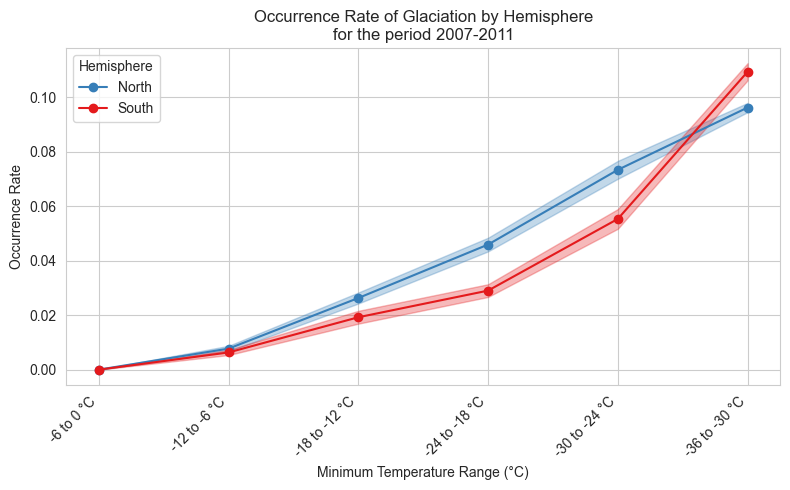

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare DataFrame
df_mean = result_mean.reset_index().rename(columns={'Occurance rate': 'mean'})
df_std  = result_std .reset_index().rename(columns={'Occurance rate': 'std'})
df = pd.merge(df_mean, df_std, on=['min_temp', 'Hemisphere'])

# Compute range strings and midpoints
df['range_str'] = df['min_temp'].apply(lambda t: f"{t} to {t+6} °C")
df['midpoint']  = df['min_temp'] + 3  # midpoint of each 6° bin

# Establish the categorical ordering of ranges
order = (
    df[['midpoint', 'range_str']]
      .drop_duplicates()
      .sort_values('midpoint')         # from coldest (smallest min_temp) to warmest
)
midpoints = order['midpoint'].tolist()
labels     = order['range_str'].tolist()

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = plt.gca()
i=0
for hemisphere, grp in df.groupby('Hemisphere'):
    grp = grp.sort_values('midpoint')
    ax.plot(grp['midpoint'], grp['mean'], marker='o', label=hemisphere,color=classifiacation_palette[(i+1)%2])
    ax.fill_between(
        grp['midpoint'],
        grp['mean'] - grp['std'],
        grp['mean'] + grp['std'],
        color=classifiacation_palette[(i+1)%2],
        alpha=0.3
    )
    i+=1


# Tick at each midpoint, labeled by the range
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Invert so coldest (smallest midpoint) is on the right
ax.invert_xaxis()

ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
ax.set_title('Occurrence Rate of Glaciation by Hemisphere\nfor the period 2007-2011')
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()


In [ ]:
# hq_pole_temp_occ_rate = hq_clouds[hq_clouds["max_water_frac"]>0.4].groupby(["pole","min_temp"]).is_glaciating.mean().reset_index(name="Occurance rate")
# hq_pole_temp_occ_rate.rename(columns={"pole":"Hemisphere"}, inplace=True)
# hq_pole_temp_occ_rate.loc[hq_pole_temp_occ_rate["Hemisphere"]=="np","Hemisphere"] = "North"
# hq_pole_temp_occ_rate.loc[hq_pole_temp_occ_rate["Hemisphere"]=="sp","Hemisphere"] = "South"
# hq_pole_temp_occ_rate.to_csv(os.path.join(GTE_DIR, "Result_analysis","Publication_figures/Multiyear_analysis","hq_pole_temp_occurance_rate_glac_possible.csv"), index=False)

: 

In [ ]:
# result_mean

min_temp  Hemisphere
-36       North         0.096156
          South         0.109282
-30       North         0.073311
          South         0.055292
-24       North         0.045894
          South         0.028998
-18       North         0.026282
          South         0.019223
-12       North         0.007712
          South         0.006307
-6        North         0.000000
          South         0.000000
Name: Occurance rate, dtype: float64

In [ ]:
result_std

min_temp  Hemisphere
-36       North         0.001706
          South         0.003139
-30       North         0.003277
          South         0.003609
-24       North         0.002507
          South         0.002334
-18       North         0.002013
          South         0.002350
-12       North         0.001023
          South         0.000954
-6        North         0.000000
          South         0.000000
Name: Occurance rate, dtype: float64

In [ ]:
pole_temp_occurance_rate

NameError: name 'pole_temp_occurance_rate' is not defined

In [ ]:
occurance_rate_with_temp

,2007,2008,2009,2010,2011
min_temp,,,,,
-36,10.483330,10.342348,10.121308,10.648339,10.623724
-30,6.089284,6.179661,5.849524,6.340262,6.743605
-24,3.537183,3.647144,3.450529,3.728339,4.062736
-18,2.160975,2.204867,2.134780,2.366077,2.653936
-12,0.671137,0.645124,0.653977,0.704925,0.880806
-6,NaN,NaN,NaN,NaN,NaN


In [ ]:
# dataset.cloud_chunk['int_is_glac'] = dataset.cloud_chunk['is_glaciating'].astype('int')


min_temp,-36,-30,-24,-18,-12,-6
Hemisphere,,,,,,
North,0.095791,0.078340,0.049849,0.029340,0.009439,0.0
South,0.112357,0.060298,0.032687,0.023225,0.007983,0.0
